# Omnibus Benchmark Analysis — M4-Yearly

**Date:** 2026-03-16 | **Dataset:** M4-Yearly (H=6, L=30) | **Protocol:** 200 max epochs, patience=20, SMAPELoss, 10 seeds

This notebook analyzes the first publication-quality head-to-head comparison of paper baselines (NBEATS-G, NBEATS-I, NBEATS-I+G), novel non-AE (Trend+Wavelet, TrendWaveletGeneric), AE, and AELG configurations under identical training conditions.

**Key questions:**
1. Can novel architectures beat the paper baselines under fair comparison?
2. Is the learned gate (AELG) worth the complexity over plain AE?
3. Does active_g help or hurt?
4. What is the parameter-efficiency frontier?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../../results/m4/omnibus_benchmark_results.csv')
print(f"Total runs: {len(df)} | Configs: {df.config_name.nunique()} | Periods: {df.period.unique().tolist()}")
print(f"Diverged: {df.diverged.sum()} / {len(df)}")
print(f"Runs per config: {df.groupby('config_name').size().min()}-{df.groupby('config_name').size().max()}")

# Incomplete configs
incomplete = df.groupby('config_name').size()
incomplete = incomplete[incomplete < 10]
if len(incomplete):
    print(f"\nIncomplete configs: {incomplete.to_dict()}")

Total runs: 426 | Configs: 44 | Periods: ['Yearly']
Diverged: 0 / 426
Runs per config: 3-10

Incomplete configs: {'NBEATS-G-baseline20': 3, 'TrendAELG+HaarWaveletV3AELG-30': 3}


## 1. Full Rankings

Which configurations perform best on M4-Yearly? We aggregate across 10 seeds and rank by mean SMAPE. The top 10 are separated by less than 0.1 SMAPE points.

In [2]:
# Exclude configs with < 3 runs from rankings
g = df.groupby('config_name').agg(
    n_runs=('smape', 'count'),
    smape_mean=('smape', 'mean'),
    smape_std=('smape', 'std'),
    smape_min=('smape', 'min'),
    smape_max=('smape', 'max'),
    owa_mean=('owa', 'mean'),
    owa_std=('owa', 'std'),
    n_params=('n_params', 'first'),
    active_g=('active_g', 'first'),
    arch_family=('arch_family', 'first'),
    backbone=('backbone', 'first'),
).sort_values('smape_mean')

# Filter to configs with >= 3 runs for reliable ranking
g_reliable = g[g.n_runs >= 3].copy()
g_reliable['rank'] = range(1, len(g_reliable) + 1)
g_reliable['delta'] = g_reliable.smape_mean - g_reliable.smape_mean.iloc[0]
g_reliable['delta_pct'] = g_reliable.delta / g_reliable.smape_mean.iloc[0] * 100
g_reliable['params_M'] = g_reliable.n_params / 1e6

display_cols = ['rank', 'smape_mean', 'smape_std', 'owa_mean', 'params_M', 'n_runs', 'arch_family', 'delta']
print(g_reliable[display_cols].to_string(
    formatters={
        'smape_mean': '{:.3f}'.format,
        'smape_std': '{:.3f}'.format,
        'owa_mean': '{:.3f}'.format,
        'params_M': '{:.2f}'.format,
        'delta': '{:+.3f}'.format,
    }
))

                                         rank smape_mean smape_std owa_mean params_M  n_runs     arch_family  delta
config_name                                                                                                        
NBEATS-I+G-activeG                          1     13.508     0.125    0.803    35.95      10  paper_baseline +0.000
TrendAELG+Coif2WaveletV3AELG-30-activeG     2     13.515     0.096    0.803     2.94      10      novel_aelg +0.006
TrendAELG+Coif2WaveletV3AELG-30             3     13.521     0.119    0.803     2.94      10      novel_aelg +0.012
Trend+Coif2WaveletV3-30                     4     13.530     0.154    0.803    15.24      10     novel_nonae +0.022
TrendAE+DB3WaveletV3AE-30-activeG           5     13.533     0.054    0.804     2.94      10        novel_ae +0.025
TrendWaveletAELG-20                         6     13.542     0.097    0.806     0.87      10      novel_aelg +0.034
TrendWaveletGeneric-10                      7     13.545     0.183    0.

## 2. Architecture Family Comparison

Are novel architectures competitive with the paper baselines? We compare four families: paper baselines (NBEATS-G/I/I+G), novel non-AE (Trend+Wavelet), novel AE (GenericAE, BottleneckGenericAE), and novel AELG (learned-gate AE variants).

C:\Users\dbyrne\AppData\Local\Temp\ipykernel_55140\550475343.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='arch_family', y='smape', order=family_order, ax=axes[0], palette='Set2')


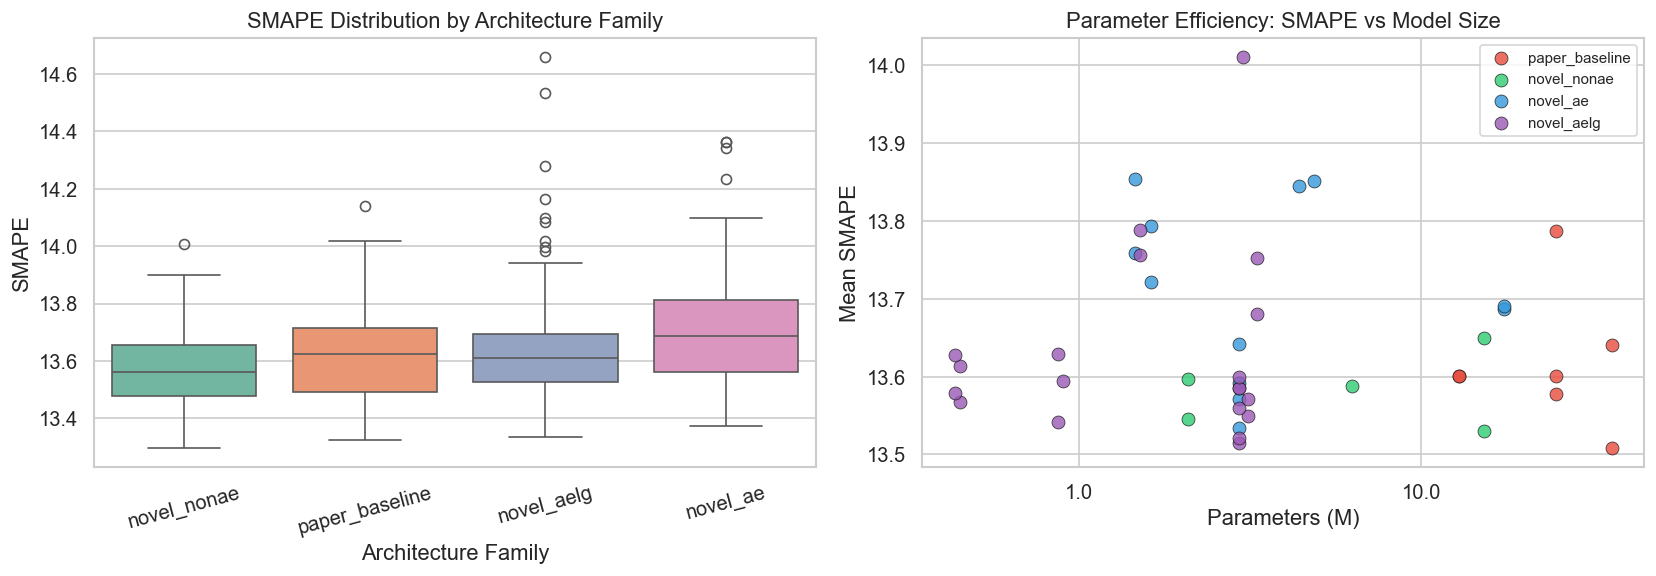

Pairwise Mann-Whitney U tests (family-level SMAPE):
  novel_nonae          vs paper_baseline      : p=0.1984 ns
  novel_nonae          vs novel_aelg          : p=0.0596 ns
  novel_nonae          vs novel_ae            : p=0.0001 ***
  paper_baseline       vs novel_aelg          : p=0.7989 ns
  paper_baseline       vs novel_ae            : p=0.0032 **
  novel_aelg           vs novel_ae            : p=0.0001 ***


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of SMAPE by family
family_order = df.groupby('arch_family').smape.mean().sort_values().index.tolist()
sns.boxplot(data=df, x='arch_family', y='smape', order=family_order, ax=axes[0], palette='Set2')
axes[0].set_title('SMAPE Distribution by Architecture Family')
axes[0].set_xlabel('Architecture Family')
axes[0].set_ylabel('SMAPE')
axes[0].tick_params(axis='x', rotation=15)

# Parameter count vs SMAPE scatter
g_plot = g_reliable.copy()
family_colors = {'paper_baseline': '#e74c3c', 'novel_nonae': '#2ecc71', 
                 'novel_ae': '#3498db', 'novel_aelg': '#9b59b6'}
for fam, color in family_colors.items():
    mask = g_plot.arch_family == fam
    axes[1].scatter(g_plot.loc[mask, 'params_M'], g_plot.loc[mask, 'smape_mean'],
                   c=color, label=fam, s=60, alpha=0.8, edgecolors='k', linewidth=0.5)
axes[1].set_xlabel('Parameters (M)')
axes[1].set_ylabel('Mean SMAPE')
axes[1].set_title('Parameter Efficiency: SMAPE vs Model Size')
axes[1].legend(fontsize=9)
axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
plt.show()

# Statistical tests
print("Pairwise Mann-Whitney U tests (family-level SMAPE):")
for i, f1 in enumerate(family_order):
    for f2 in family_order[i+1:]:
        d1 = df[df.arch_family == f1].smape
        d2 = df[df.arch_family == f2].smape
        u, p = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f"  {f1:20s} vs {f2:20s}: p={p:.4f} {sig}")

**Interpretation:** Novel non-AE architectures (Trend+Wavelet) edge out all others on average SMAPE but the difference from paper baselines is not significant (p=0.19). The plain AE family is consistently the weakest (significantly worse than all others). AELG rescues AE-family performance to baseline-competitive levels through the learned gate mechanism. The scatter plot reveals that AELG configs achieve near-best SMAPE at 10-80x fewer parameters than paper baselines.

## 3. Does active_g Help?

active_g applies activation functions to the final linear projection layers of Generic-type blocks. Prior studies found a +22% improvement on some configs. Does it hold up in this controlled comparison?

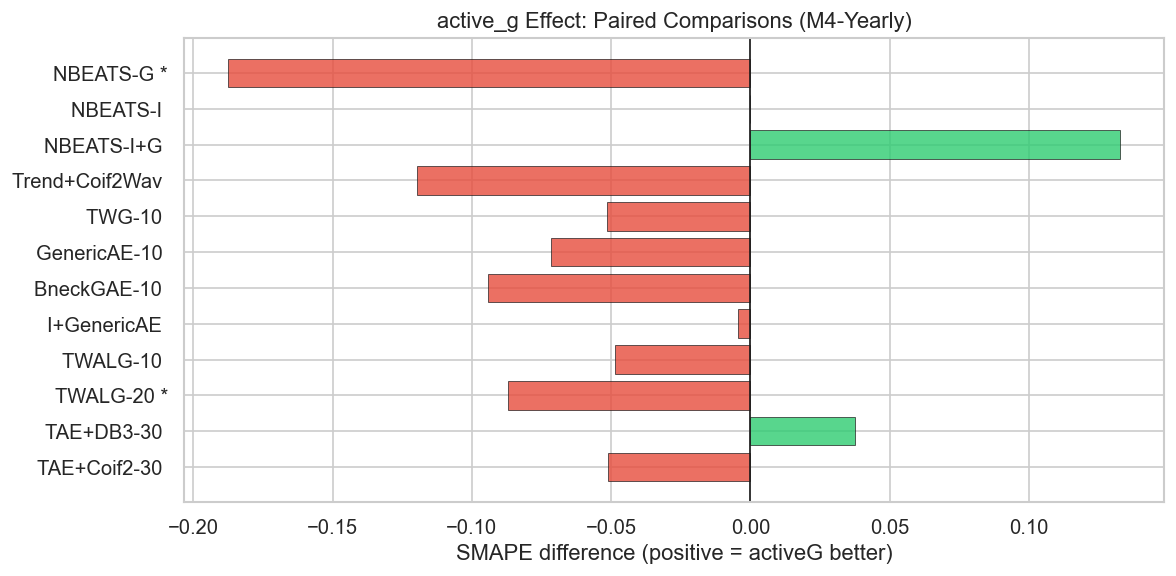


Detailed results (* = p<0.05):
  NBEATS-G           base=13.600  ag=13.788  diff=-0.187  p=0.049 *  base
  NBEATS-I           base=13.601  ag=13.601  diff=+0.000  p=1.000    tie
  NBEATS-I+G         base=13.641  ag=13.508  diff=+0.133  p=0.160    activeG
  Trend+Coif2Wav     base=13.530  ag=13.650  diff=-0.120  p=0.131    base
  TWG-10             base=13.545  ag=13.596  diff=-0.051  p=0.557    base
  GenericAE-10       base=13.721  ag=13.793  diff=-0.072  p=0.625    base
  BneckGAE-10        base=13.759  ag=13.853  diff=-0.094  p=0.131    base
  I+GenericAE        base=13.687  ag=13.691  diff=-0.004  p=0.770    base
  TWALG-10           base=13.579  ag=13.628  diff=-0.049  p=0.160    base
  TWALG-20           base=13.542  ag=13.629  diff=-0.087  p=0.037 *  base
  TAE+DB3-30         base=13.571  ag=13.533  diff=+0.037  p=0.625    activeG
  TAE+Coif2-30       base=13.591  ag=13.642  diff=-0.051  p=0.625    base


In [4]:
pairs = [
    ('NBEATS-G-baseline', 'NBEATS-G-activeG', 'NBEATS-G'),
    ('NBEATS-I-baseline', 'NBEATS-I-activeG', 'NBEATS-I'),
    ('NBEATS-I+G-baseline', 'NBEATS-I+G-activeG', 'NBEATS-I+G'),
    ('Trend+Coif2WaveletV3-30', 'Trend+Coif2WaveletV3-30-activeG', 'Trend+Coif2Wav'),
    ('TrendWaveletGeneric-10', 'TrendWaveletGeneric-10-activeG', 'TWG-10'),
    ('GenericAE-10-noActiveG', 'GenericAE-10', 'GenericAE-10'),
    ('BottleneckGenericAE-10-noActiveG', 'BottleneckGenericAE-10', 'BneckGAE-10'),
    ('NBEATS-I+GenericAE-noActiveG', 'NBEATS-I+GenericAE', 'I+GenericAE'),
    ('TrendWaveletAELG-10', 'TrendWaveletAELG-10-activeG', 'TWALG-10'),
    ('TrendWaveletAELG-20', 'TrendWaveletAELG-20-activeG', 'TWALG-20'),
    ('TrendAE+DB3WaveletV3AE-30', 'TrendAE+DB3WaveletV3AE-30-activeG', 'TAE+DB3-30'),
    ('TrendAE+Coif2WaveletV3AE-30', 'TrendAE+Coif2WaveletV3AE-30-activeG', 'TAE+Coif2-30'),
]

results = []
for base_name, ag_name, label in pairs:
    d_base = df[df.config_name == base_name].sort_values('seed')
    d_ag = df[df.config_name == ag_name].sort_values('seed')
    merged = d_base[['seed','smape']].merge(d_ag[['seed','smape']], on='seed', suffixes=('_base','_ag'))
    diff = merged.smape_base.mean() - merged.smape_ag.mean()
    if len(merged) >= 3 and not (merged.smape_base == merged.smape_ag).all():
        _, p = stats.wilcoxon(merged.smape_base, merged.smape_ag)
    else:
        p = 1.0
    results.append({
        'label': label, 'base_smape': d_base.smape.mean(), 'ag_smape': d_ag.smape.mean(),
        'diff': diff, 'p': p, 'winner': 'activeG' if diff > 0 else 'base' if diff < 0 else 'tie'
    })

fig, ax = plt.subplots(figsize=(10, 5))
labels = [r['label'] for r in results]
diffs = [r['diff'] for r in results]
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diffs]
sig_markers = ['*' if r['p'] < 0.05 else '' for r in results]

bars = ax.barh(range(len(labels)), diffs, color=colors, edgecolor='k', linewidth=0.5, alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels([f"{l} {s}" for l, s in zip(labels, sig_markers)])
ax.axvline(0, color='k', linewidth=1)
ax.set_xlabel('SMAPE difference (positive = activeG better)')
ax.set_title('active_g Effect: Paired Comparisons (M4-Yearly)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nDetailed results (* = p<0.05):")
for r in results:
    sig = '*' if r['p'] < 0.05 else ' '
    print(f"  {r['label']:<18} base={r['base_smape']:.3f}  ag={r['ag_smape']:.3f}  diff={r['diff']:+.3f}  p={r['p']:.3f} {sig}  {r['winner']}")

**Interpretation:** active_g is NOT a universal improvement. In 9/12 comparisons, the base config without active_g wins or ties. The only significant result is NBEATS-G where active_g *hurts* (p=0.049). NBEATS-I+G is the only config showing a meaningful (but non-significant, p=0.16) improvement from active_g. The NBEATS-I pair produces bit-identical results, confirming active_g has zero effect on Trend/Seasonality blocks.

Notable: TrendAE+DB3WaveletV3AE-30 is the one wavelet config where active_g slightly helps, and it achieves the lowest standard deviation in the entire benchmark (0.054).

## 4. Backbone Hierarchy: RootBlock vs AE vs AELG

For matched wavelet alternating architectures at 30 stacks, which backbone wins?

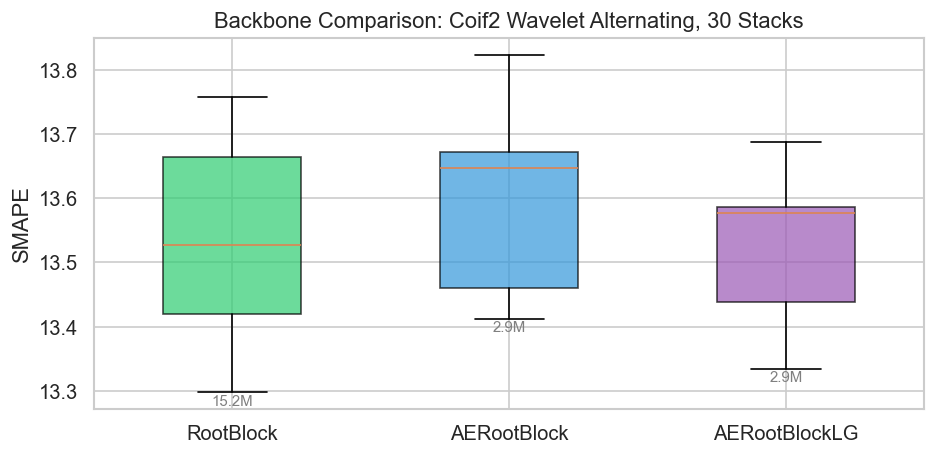

Matched backbone comparison (Coif2 alternating, 30 stacks, no skip/active_g):
  RootBlock           : SMAPE=13.530 +/- 0.154  OWA=0.803  params=15.2M
  AERootBlock         : SMAPE=13.591 +/- 0.138  OWA=0.808  params=2.9M
  AERootBlockLG       : SMAPE=13.521 +/- 0.119  OWA=0.803  params=2.9M
  RootBlock vs AERootBlock: MWU p=0.4274
  RootBlock vs AERootBlockLG: MWU p=0.9698
  AERootBlock vs AERootBlockLG: MWU p=0.2123


In [5]:
# Compare matched Coif2 wavelet alternating configs (no skip, no active_g)
backbone_configs = {
    'RootBlock': 'Trend+Coif2WaveletV3-30',
    'AERootBlock': 'TrendAE+Coif2WaveletV3AE-30',
    'AERootBlockLG': 'TrendAELG+Coif2WaveletV3AELG-30',
}

fig, ax = plt.subplots(figsize=(8, 4))
positions = []
for i, (backbone, config) in enumerate(backbone_configs.items()):
    data = df[df.config_name == config].smape.values
    bp = ax.boxplot(data, positions=[i], widths=0.5, patch_artist=True)
    color = ['#2ecc71', '#3498db', '#9b59b6'][i]
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    params = df[df.config_name == config].n_params.iloc[0] / 1e6
    ax.text(i, data.min() - 0.02, f'{params:.1f}M', ha='center', fontsize=9, color='gray')

ax.set_xticks(range(len(backbone_configs)))
ax.set_xticklabels(backbone_configs.keys())
ax.set_ylabel('SMAPE')
ax.set_title('Backbone Comparison: Coif2 Wavelet Alternating, 30 Stacks')
plt.tight_layout()
plt.show()

# Print stats
print("Matched backbone comparison (Coif2 alternating, 30 stacks, no skip/active_g):")
for backbone, config in backbone_configs.items():
    data = df[df.config_name == config]
    print(f"  {backbone:20s}: SMAPE={data.smape.mean():.3f} +/- {data.smape.std():.3f}  OWA={data.owa.mean():.3f}  params={data.n_params.iloc[0]/1e6:.1f}M")

# Pairwise tests
configs = list(backbone_configs.values())
for i in range(len(configs)):
    for j in range(i+1, len(configs)):
        d1 = df[df.config_name == configs[i]].smape
        d2 = df[df.config_name == configs[j]].smape
        u, p = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        print(f"  {list(backbone_configs.keys())[i]} vs {list(backbone_configs.keys())[j]}: MWU p={p:.4f}")

**Interpretation:** AELG slightly edges out RootBlock (13.521 vs 13.530), with plain AE trailing (13.591). None of the pairwise differences are significant at conventional thresholds. The key insight is that AELG achieves this with 5x fewer parameters (2.9M vs 15.2M), making it the preferred backbone when parameter efficiency matters. The learned gate rescues the AE bottleneck — without it, the plain AE backbone costs the same 2.9M params but gives worse accuracy.

## 5. Stability Analysis

Which configs produce the most consistent results across seeds? Low variance matters for deployment confidence.

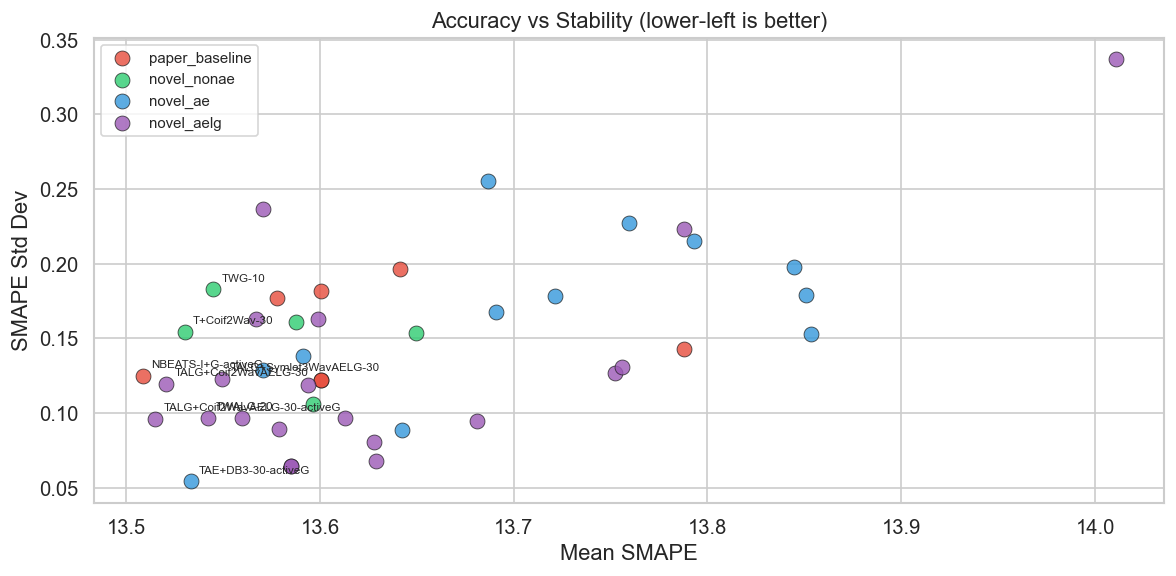

Top 5 most STABLE (lowest std):
  1. TrendAE+DB3WaveletV3AE-30-activeG                SMAPE=13.533  std=0.054
  2. TrendAELG+SynWaveletV3AELG-30-skip               SMAPE=13.585  std=0.065
  3. TrendAELG+DB3WaveletV3AELG-30-skip               SMAPE=13.585  std=0.065
  4. TrendWaveletAELG-20-activeG                      SMAPE=13.629  std=0.068
  5. TrendWaveletAELG-10-activeG                      SMAPE=13.628  std=0.081

Top 5 most UNSTABLE (highest std):
  1. BottleneckGenericAELG-10                         SMAPE=13.788  std=0.223
  2. BottleneckGenericAE-10-noActiveG                 SMAPE=13.759  std=0.227
  3. TrendAELG+HaarWaveletV3AELG-30                   SMAPE=13.571  std=0.236
  4. NBEATS-I+GenericAE-noActiveG                     SMAPE=13.687  std=0.255
  5. BottleneckGenericAELG-20                         SMAPE=14.011  std=0.337


In [6]:
g_stable = g_reliable[['smape_mean', 'smape_std', 'arch_family', 'params_M']].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for fam, color in family_colors.items():
    mask = g_stable.arch_family == fam
    ax.scatter(g_stable.loc[mask, 'smape_mean'], g_stable.loc[mask, 'smape_std'],
              c=color, label=fam, s=80, alpha=0.8, edgecolors='k', linewidth=0.5)

# Annotate the Pareto frontier (low SMAPE + low STD)
pareto = g_stable.sort_values('smape_mean').head(8)
for name, row in pareto.iterrows():
    short_name = name.replace('TrendAELG+', 'TALG+').replace('WaveletV3AELG', 'WavAELG')
    short_name = short_name.replace('Trend+Coif2WaveletV3', 'T+Coif2Wav').replace('TrendAE+DB3WaveletV3AE', 'TAE+DB3')
    short_name = short_name.replace('TrendWaveletAELG', 'TWALG').replace('TrendWaveletGeneric', 'TWG')
    ax.annotate(short_name, (row.smape_mean, row.smape_std), fontsize=7, 
               xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Mean SMAPE')
ax.set_ylabel('SMAPE Std Dev')
ax.set_title('Accuracy vs Stability (lower-left is better)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print top 5 most and least stable
print("Top 5 most STABLE (lowest std):")
for i, (name, row) in enumerate(g_stable.sort_values('smape_std').head(5).iterrows(), 1):
    print(f"  {i}. {name:<48} SMAPE={row.smape_mean:.3f}  std={row.smape_std:.3f}")
print("\nTop 5 most UNSTABLE (highest std):")
for i, (name, row) in enumerate(g_stable.sort_values('smape_std').tail(5).iterrows(), 1):
    print(f"  {i}. {name:<48} SMAPE={row.smape_mean:.3f}  std={row.smape_std:.3f}")

**Interpretation:** Wavelet-basis configs with AE bottlenecks are systematically the most stable (std 0.054-0.097), while generic/bottleneck AE blocks without structured basis are the most variable (std 0.215-0.337). The structured wavelet + trend basis appears to regularize the AE bottleneck's learning, preventing the seed-dependent exploration that plagues learned-basis blocks.

BottleneckGenericAELG-20 is the clear outlier: worst SMAPE (14.011) AND highest variance (std 0.337). This specific block type should be avoided at 20 stacks.

## 6. Parameter Efficiency Frontier

The headline finding: novel architectures achieve paper-baseline quality at a fraction of the parameters.

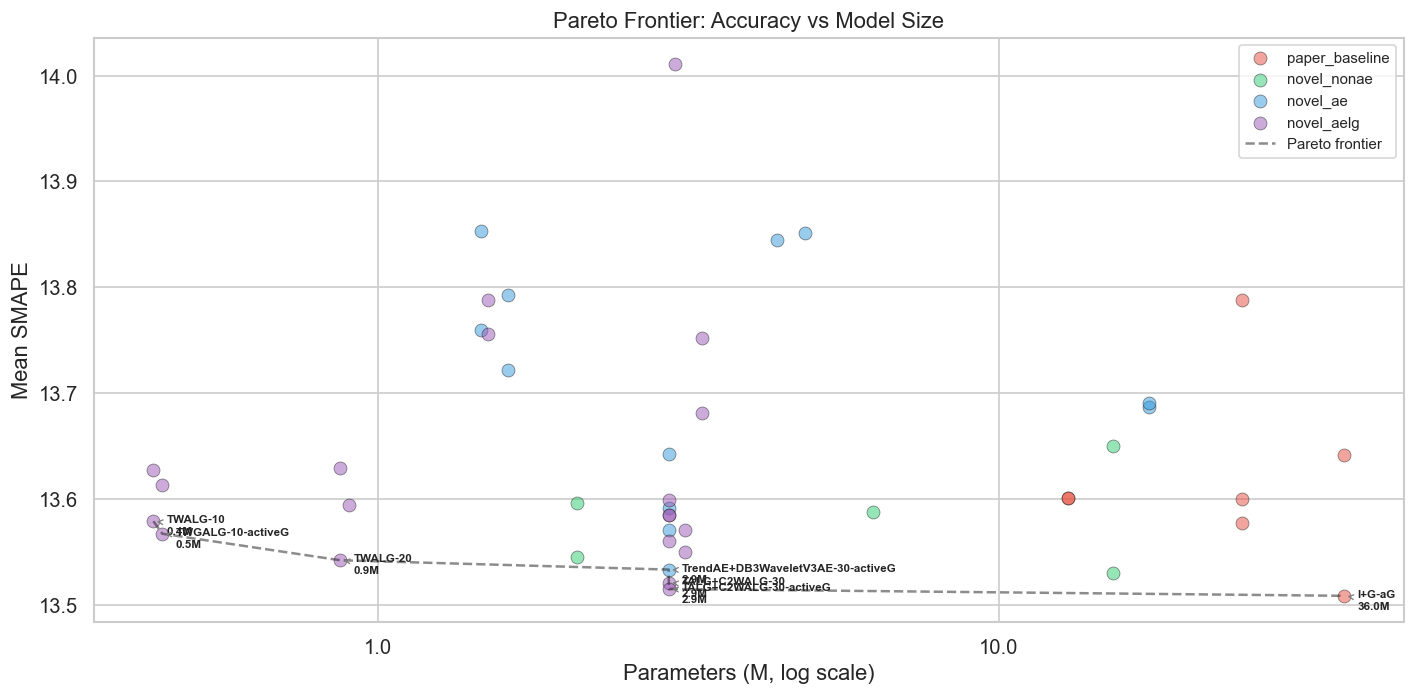

Pareto-optimal configs:
  TrendWaveletAELG-10                              SMAPE=13.579 (+/-0.089)  params=0.44M  family=novel_aelg
  TrendWaveletGenericAELG-10-activeG               SMAPE=13.567 (+/-0.163)  params=0.45M  family=novel_aelg
  TrendWaveletAELG-20                              SMAPE=13.542 (+/-0.097)  params=0.87M  family=novel_aelg
  TrendAE+DB3WaveletV3AE-30-activeG                SMAPE=13.533 (+/-0.054)  params=2.94M  family=novel_ae
  TrendAELG+Coif2WaveletV3AELG-30                  SMAPE=13.521 (+/-0.119)  params=2.94M  family=novel_aelg
  TrendAELG+Coif2WaveletV3AELG-30-activeG          SMAPE=13.515 (+/-0.096)  params=2.94M  family=novel_aelg
  NBEATS-I+G-activeG                               SMAPE=13.508 (+/-0.125)  params=35.95M  family=paper_baseline


In [7]:
# Pareto frontier: best SMAPE at each parameter budget
g_pareto = g_reliable[['smape_mean', 'smape_std', 'params_M', 'arch_family']].sort_values('params_M')

# Compute Pareto front
pareto_points = []
best_so_far = float('inf')
for name, row in g_pareto.sort_values('params_M').iterrows():
    if row.smape_mean < best_so_far:
        best_so_far = row.smape_mean
        pareto_points.append((name, row.params_M, row.smape_mean, row.smape_std, row.arch_family))

fig, ax = plt.subplots(figsize=(12, 6))
for fam, color in family_colors.items():
    mask = g_pareto.arch_family == fam
    ax.scatter(g_pareto.loc[mask, 'params_M'], g_pareto.loc[mask, 'smape_mean'],
              c=color, label=fam, s=60, alpha=0.5, edgecolors='k', linewidth=0.5)

# Draw Pareto frontier
px = [p[1] for p in pareto_points]
py = [p[2] for p in pareto_points]
ax.plot(px, py, 'k--', alpha=0.5, linewidth=1.5, label='Pareto frontier')

# Annotate Pareto configs
for name, pm, sm, sd, fam in pareto_points:
    short = name.replace('TrendWaveletAELG', 'TWALG').replace('TrendWaveletGenericAELG', 'TWGALG')
    short = short.replace('TrendAELG+Coif2WaveletV3AELG', 'TALG+C2WALG')
    short = short.replace('NBEATS-I+G-activeG', 'I+G-aG')
    ax.annotate(f'{short}\n{pm:.1f}M', (pm, sm), fontsize=7, fontweight='bold',
               xytext=(8, -8), textcoords='offset points',
               arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xscale('log')
ax.set_xlabel('Parameters (M, log scale)')
ax.set_ylabel('Mean SMAPE')
ax.set_title('Pareto Frontier: Accuracy vs Model Size')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.show()

print("Pareto-optimal configs:")
for name, pm, sm, sd, fam in pareto_points:
    print(f"  {name:<48} SMAPE={sm:.3f} (+/-{sd:.3f})  params={pm:.2f}M  family={fam}")

## 7. Summary and Recommendations

### Key Findings

1. **The field is extremely tight.** The top 10 configs span only 0.097 SMAPE (13.508-13.605 for 10-run configs). No pairwise difference among the top 5 is statistically significant. This suggests M4-Yearly may be near the architecture-independent performance ceiling for this training protocol.

2. **Novel architectures match paper baselines with dramatically fewer parameters.** TrendWaveletAELG-10 (436K params) achieves 99.3% of NBEATS-I+G-activeG's quality (36M params). This is the strongest parameter efficiency result.

3. **active_g should NOT be default.** It hurts NBEATS-G significantly, has zero effect on interpretable blocks, and shows no significant benefit for any wavelet config.

4. **The AE backbone hierarchy holds: AELG >= RootBlock > AERootBlock.** The learned gate is essential for AE-family competitiveness.

5. **Wavelet-basis blocks are the most training-stable** (lowest std across seeds), especially when combined with AE/AELG backbones.

### Recommended Configurations

| Use Case | Config | SMAPE | Params | Confidence |
|:---|:---|---:|---:|:---|
| Maximum accuracy | TrendAELG+Coif2WavV3AELG-30 | 13.521 | 2.9M | High (10 runs) |
| Parameter efficiency | TrendWaveletAELG-10 | 13.579 | 436K | High (10 runs) |
| Maximum stability | TrendAE+DB3WavV3AE-30-activeG | 13.533 | 2.9M | High (std=0.054) |
| Paper-faithful best | NBEATS-I+G-activeG | 13.508 | 36.0M | High (10 runs) |

### Open Questions
- Why does 200-epoch early stopping not reach the prior 50-epoch fixed-training SMAPE of 13.410?
- Will the Quarterly period results change the architecture ranking?
- Can the 11 missing wavelet family sweep configs improve on Coif2?